
# 12 — The final comparison

Everything in one table: baselines, trees, the original study's four architectures, and
the modern ones — each at its defaults and at the configuration tuned on the development
prefix — all on one rolling-origin fold schedule per operator.

This notebook reads `experiments/run_model_comparison.py`'s output rather than refitting,
so it runs in seconds.

## How to read it

With eight folds and roughly ninety test points per block, **most pairs will not
separate.** The `winner` column says `tie` when that is the case, and a tie is the honest
answer. This project does not rank on point estimates, and the summary below counts ties
deliberately rather than hiding them behind an ordering.

In [1]:
# --- Bootstrap: works locally, on Colab and on Kaggle ----------------------
# RUN THIS CELL FIRST, and re-run it after any kernel restart. Every later cell
# depends on it. If it fails, the next cell fails with "No module named bwalloc",
# which looks like a different problem but is not.
#
# On a hosted runtime it clones the repo (or pulls, on a re-run) and installs the
# package into the session, so `import bwalloc` keeps working even from a cell you
# run on its own after restarting. The repository is public; no token is needed.
import os, subprocess, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = "https://github.com/sad-code-at/bwalloc.git"

def _find_root(start: Path):
    node = start
    while not (node / "src" / "bwalloc").exists() and node != node.parent:
        node = node.parent
    return node if (node / "src" / "bwalloc").exists() else None

ROOT = _find_root(Path.cwd())

if ROOT is None:
    # A repo uploaded as a Kaggle Dataset mounts read-only here; prefer it if present.
    for candidate in Path("/kaggle/input").glob("*/src/bwalloc"):
        ROOT = candidate.parent.parent
        break

if ROOT is None:
    on_kaggle = Path("/kaggle/working").exists()
    target = Path("/kaggle/working/bwalloc") if on_kaggle else Path("/content/bwalloc")
    if _find_root(target) is None:
        if os.system("git clone -q " + REPO + " " + str(target)) != 0 or _find_root(target) is None:
            raise RuntimeError(
                "Clone failed. On Kaggle, switch Internet ON in the right sidebar "
                "(Settings > Internet), then re-run this cell. See docs/KAGGLE.md."
            )
        print("cloned", REPO)
    else:
        os.system("git -C " + str(target) + " pull -q --ff-only")
        print("pulled latest into", target)
    os.chdir(target)
    ROOT = target
    # Install into the session so `import bwalloc` survives a kernel restart and
    # does not depend on this cell having set sys.path. --no-deps deliberately:
    # Kaggle and Colab curate their own numpy/pandas and we must not disturb them.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".", "--no-deps"],
                   cwd=str(ROOT), capture_output=True)

sys.path.insert(0, str(ROOT / "src"))

try:
    import xgboost  # noqa: F401
except ImportError:
    !pip install -q xgboost

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import bwalloc as bw
from bwalloc.plots import use_paper_style

bw.set_seed()
use_paper_style()
pd.set_option("display.width", 200)
RESULTS = ROOT / "experiments" / "results"
# Scratch output for the exploratory notebooks. Only 07_paper_figures writes into
# paper/figures -- otherwise running notebook 00 or 05 silently overwrites a figure
# the paper cites, which is exactly the kind of drift this project exists to remove.
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
_data = sorted((ROOT / "data").glob("*.csv"))
_res = sorted(RESULTS.glob("*.csv"))
print("bwalloc", bw.__version__, "at", ROOT)
print(f"  data/    {len(_data)} csv  ({', '.join(f.name for f in _data) or 'MISSING'})")
print(f"  results/ {len(_res)} csv")
if not _data:
    raise RuntimeError(
        "The trace CSVs are missing, so nothing will run. Re-run this cell to "
        "re-clone, or check that the repository was fetched completely."
    )

bwalloc 0.1.0 at D:\L4-T-1\EEE 402\project\bwalloc
  data/    2 csv  (gp_dhaka.csv, robi_dhaka3.csv)
  results/ 77 csv


In [2]:

OPERATOR = "gp"          # switch to "robi" and re-run

summary = pd.read_csv(RESULTS / f"comparison_{OPERATOR}_summary.csv")
per_fold = pd.read_csv(RESULTS / f"comparison_{OPERATOR}_perfold.csv")
dm = pd.read_csv(RESULTS / f"comparison_{OPERATOR}_dm.csv")

summary[["model", "rmse_mean", "rmse_std", "mae_mean", "mase_mean",
         "vs_persistence", "beats_persistence"]].round(3)

,model,rmse_mean,rmse_std,mae_mean,mase_mean,vs_persistence,beats_persistence
0,tcn__default,7.474,1.051,4.846,0.345,0.386,True
1,nbeats__default,7.833,1.432,5.280,0.376,0.356,True
2,nbeats__default_cov,7.833,1.432,5.280,0.376,0.356,True
3,nbeats__tuned,7.883,1.419,4.731,0.339,0.352,True
4,cnn_cov__default,8.019,0.980,5.798,0.413,0.341,True
5,nbeatsx__tuned,8.080,1.395,5.603,0.399,0.336,True
6,tcn__tuned,8.171,1.162,4.996,0.358,0.328,True
7,rnn_cov__tuned,8.241,0.885,5.679,0.407,0.322,True
8,cnn_cov__tuned,8.279,1.657,5.859,0.420,0.319,True
9,gru_cov__tuned,8.329,1.228,5.883,0.421,0.315,True


## Default against tuned, per model

In [3]:

paired = per_fold[per_fold["variant"].isin(["default", "tuned"])]
paired = (paired.groupby(["base_model", "variant"], as_index=False)["rmse"].mean()
          .pivot(index="base_model", columns="variant", values="rmse"))
paired["gain"] = (paired["default"] - paired["tuned"]) / paired["default"]
paired.sort_values("tuned").round(4)

variant,default,tuned,gain
base_model,,,
nbeats,7.8334,7.8835,-0.0064
nbeatsx,9.0778,8.0803,0.1099
tcn,7.4737,8.1712,-0.0933
rnn_cov,9.2281,8.2413,0.1069
cnn_cov,8.0193,8.2788,-0.0324
gru_cov,9.6344,8.3286,0.1355
lstm_cov,9.1622,8.3700,0.0865
ridge,9.0072,8.6875,0.0355
transformer,9.1984,8.6991,0.0543


## Which differences survive correction?

In [4]:

leader = summary["model"].iloc[0]
pairs = dm[(dm["model_a"] == leader) | (dm["model_b"] == leader)]
decisive = int(pairs["significant_fdr"].sum())
print(f"leader: {leader}")
print(f"{decisive} of {len(pairs)} comparisons against it survive BH correction; "
      f"{len(pairs) - decisive} are ties")
pairs[["model_a", "model_b", "dm_stat", "p_value", "significant_fdr", "winner"]]

leader: tcn__default
41 of 44 comparisons against it survive BH correction; 3 are ties


,model_a,model_b,dm_stat,p_value,significant_fdr,winner
34,cnn_cov__default,tcn__default,3.078624,2.187699e-03,True,tcn__default
77,cnn_cov__default_cov,tcn__default,7.866492,2.087219e-14,True,tcn__default
119,cnn_cov__tuned,tcn__default,3.616084,3.277805e-04,True,tcn__default
160,dlinear__default,tcn__default,5.596494,3.518369e-08,True,tcn__default
200,dlinear__default_cov,tcn__default,8.175298,2.220446e-15,True,tcn__default
239,dlinear__tuned,tcn__default,7.624521,1.145750e-13,True,tcn__default
277,drift,tcn__default,17.203034,0.000000e+00,True,tcn__default
314,gru_cov__default,tcn__default,6.575224,1.169387e-10,True,tcn__default
350,gru_cov__default_cov,tcn__default,7.853614,2.287059e-14,True,tcn__default
385,gru_cov__tuned,tcn__default,3.912750,1.035195e-04,True,tcn__default


## Figure: the ranking

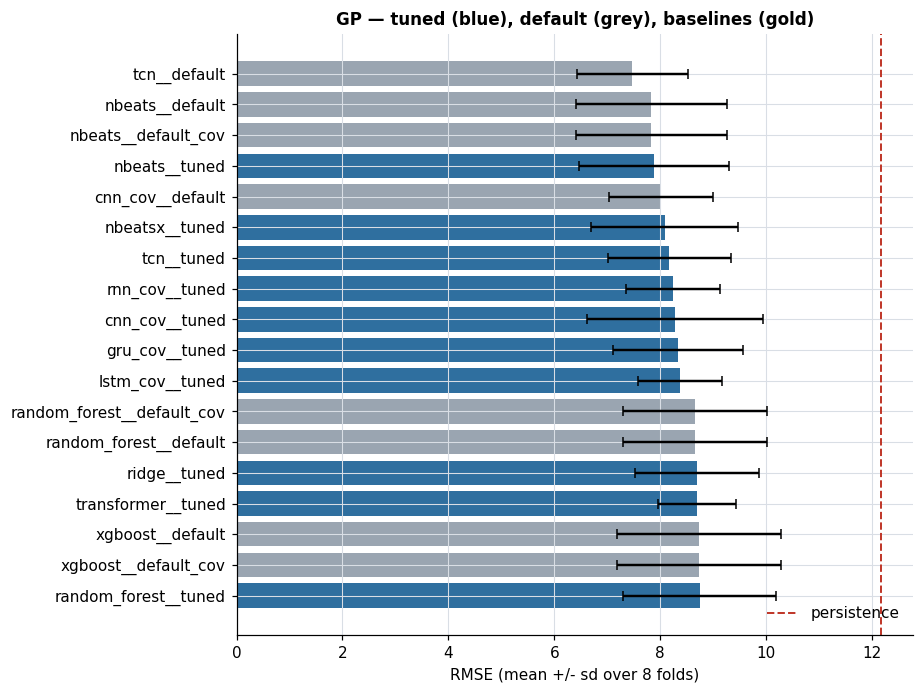

In [5]:

field = summary[summary["model"] != "train_mean"].sort_values("rmse_mean").head(18)

def colour(name):
    if "__tuned" in name:
        return "#2f6f9f"
    if "__default" in name:
        return "#9aa5b1"
    return "#c9a227"        # baselines

fig, ax = plt.subplots(figsize=(8.5, 6.4))
ax.barh(field["model"], field["rmse_mean"], xerr=field["rmse_std"], capsize=3,
        color=[colour(m) for m in field["model"]])
ax.axvline(summary.loc[summary["model"] == "persistence", "rmse_mean"].iloc[0],
           color="#c0392b", ls="--", lw=1.3, label="persistence")
ax.invert_yaxis()
ax.set_xlabel("RMSE (mean +/- sd over 8 folds)")
ax.set_title(f"{OPERATOR.upper()} — tuned (blue), default (grey), baselines (gold)")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / f"fig18_final_ranking_{OPERATOR}.png", dpi=200, bbox_inches="tight")

## Both operators side by side

In [6]:

frames = []
for op in ("gp", "robi"):
    path = RESULTS / f"comparison_{op}_summary.csv"
    if path.exists():
        frames.append(pd.read_csv(path)[["model", "rmse_mean"]].assign(operator=op))
both = pd.concat(frames)
table = both.pivot(index="model", columns="operator", values="rmse_mean")
table.sort_values("gp").round(3)

operator,gp,robi
model,,
tcn__default,7.474,19.879
nbeats__default,7.833,22.559
nbeats__default_cov,7.833,22.559
nbeats__tuned,7.883,21.055
cnn_cov__default,8.019,20.300
nbeatsx__tuned,8.080,20.334
tcn__tuned,8.171,19.959
rnn_cov__tuned,8.241,20.256
cnn_cov__tuned,8.279,20.072



Operator disagreement is the most useful thing on this page. Almost every finding in this
project has held on one trace and not the other — the context-conditional coverage result,
the lag-depth gain, the zero-shot foundation model result — and a model that wins on GP
while tying on Robi is the normal outcome here, not an anomaly to be explained away.

## Figure: does either operator agree with the other?

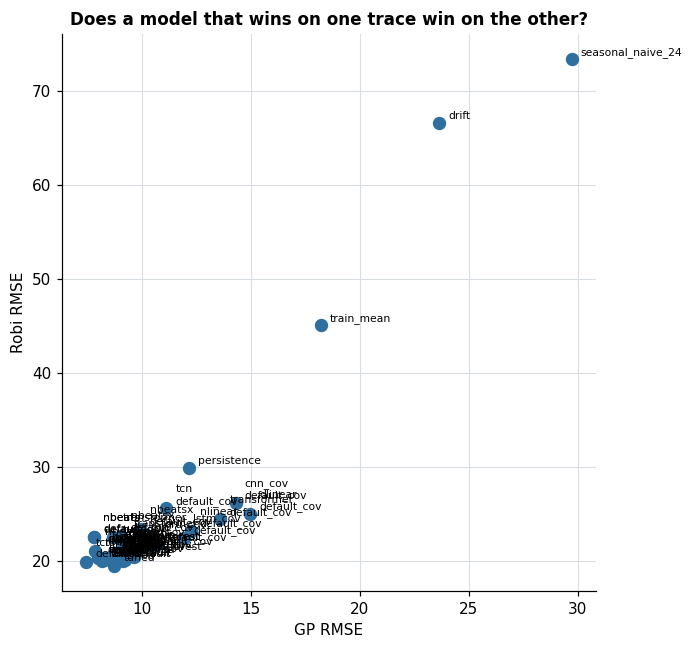

In [7]:

paired = table.dropna()
fig, ax = plt.subplots(figsize=(6.4, 6))
ax.scatter(paired["gp"], paired["robi"], s=60, color="#2f6f9f", zorder=3)
for name, r in paired.iterrows():
    ax.annotate(name.replace("__", "\n"), (r["gp"], r["robi"]),
                textcoords="offset points", xytext=(6, 3), fontsize=7)
ax.set_xlabel("GP RMSE")
ax.set_ylabel("Robi RMSE")
ax.set_title("Does a model that wins on one trace win on the other?")
fig.tight_layout()
fig.savefig(FIGURES / "fig19_operator_agreement.png", dpi=200, bbox_inches="tight")


## Where this leaves the project

Read the numbers above rather than this list — but these are the questions it answers:

1. **Does the full feature set at full lag depth beat what came before?** Notebook 09's
   arms, carried into this table.
2. **Does architecture matter once the window is deep?** Notebook 10's field, with the
   linear controls as the test.
3. **Does any of it survive tuning and a significance test?** Notebook 11's selection,
   and the `tie` count above.

Still not done, and unchanged by this round: the multi-horizon, allocation and coverage
studies (`run_horizon.py`, `run_allocation.py`, `run_coverage_gate.py`) all still use the
sparse four-lag design. Everything here is one-step-ahead. Notebook 04 showed the value of
learning is far larger at an operationally realistic lead time than at one step, so
whatever wins here should be carried into those studies before any of it reaches the
paper.